##### Before diving in, it's important to understand the scope of this work. This is an end-to-end machine learning project aimed at predicting property rental prices in the UAE. The repository includes raw and processed data, trained models, and Python scripts for building interactive dashboards. It serves as a state-of-the-art implementation, showcasing exactly how a real-world ML project should be approached from initial problem definition all the way to deployment. I built this specifically to help students who want to learn how to construct a complete ML pipeline. Having been a student myself, I know firsthand that your chances of being taught these practical, industry-ready skills in a traditional classroom are incredibly slim. Through this project, I will walk you step-by-step through my personal ML engineering workflow.

##### Whether you're a beginner or a seasoned professional, I hope you find this guide genuinely helpful. If you get value out of this project, please don't hesitate to share it with your peers and leave a star to support the craftsmanship!

In [2]:
import sys
from pathlib import Path
sys.path.append("../")  # so the notebook can find analyze_src as a package

import pandas as pd
from analyze_src.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis
from analyze_src.outlier_analysis import OutlierAnalyzer, IQROutlierDetection, PercentileOutlierDetection

from src.data_ingestion import DataIngestorFactory

##### 1. Extraction of the dataset from archive.zip in [../data/raw/archive.zip]

In [3]:
archive_path = Path("../data/raw/archive.zip")
extract_dir = Path("../data/raw")

ingestor = DataIngestorFactory.get_data_ingestor(archive_path)
df = ingestor.ingest(archive_path, extract_dir)

df.head(5)

Successfully loaded 'dubai_properties.csv' (73742 rows, 17 cols) into a DataFrame.


,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
0,"The Gate Tower 2, The Gate Tower, Shams Gate D...",124000,3,4,Apartment,1785,69.467787,Medium,Yearly,Unfurnished,For Rent,2024-03-07,45,Al Reem Island,Abu Dhabi,24.493598,54.407841
1,"Water's Edge, Yas Island, Abu Dhabi",140000,3,4,Apartment,1422,98.452883,Medium,Yearly,Unfurnished,For Rent,2024-03-08,44,Yas Island,Abu Dhabi,24.494022,54.607372
2,"Al Raha Lofts, Al Raha Beach, Abu Dhabi",99000,2,3,Apartment,1314,75.342466,Medium,Yearly,Furnished,For Rent,2024-03-21,31,Al Raha Beach,Abu Dhabi,24.485931,54.600939
3,"Marina Heights, Marina Square, Al Reem Island,...",220000,3,4,Penthouse,3843,57.246942,High,Yearly,Unfurnished,For Rent,2024-02-24,57,Al Reem Island,Abu Dhabi,24.493598,54.407841
4,"West Yas, Yas Island, Abu Dhabi",350000,5,7,Villa,6860,51.020408,High,Yearly,Unfurnished,For Rent,2024-02-16,65,Yas Island,Abu Dhabi,24.494022,54.607372


In [4]:
df = pd.read_csv("../data/raw/dubai_properties.csv")

##### 2. Basic inspection

In [5]:

inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(df)


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73742 entries, 0 to 73741
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Address                 73742 non-null  object 
 1   Rent                    73742 non-null  int64  
 2   Beds                    73742 non-null  int64  
 3   Baths                   73742 non-null  int64  
 4   Type                    73742 non-null  object 
 5   Area_in_sqft            73742 non-null  int64  
 6   Rent_per_sqft           73742 non-null  float64
 7   Rent_category           73742 non-null  object 
 8   Frequency               73742 non-null  object 
 9   Furnishing              73742 non-null  object 
 10  Purpose                 73742 non-null  object 
 11  Posted_date             73742 non-null  object 
 12  Age_of_listing_in_days  73742 non-null  int64  
 13  Location                73742 non-null  object 
 14  City 

In [6]:
inspector.set_strategy(SummaryStatisticsInspectionStrategy())
inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
               Rent          Beds         Baths   Area_in_sqft  Rent_per_sqft  \
count  7.374200e+04  73742.000000  73742.000000   73742.000000   73742.000000   
mean   1.479250e+05      2.162811      2.650213    2054.053552      88.057754   
std    3.069658e+05      1.578155      1.632997    3003.919252      66.534400   
min    0.000000e+00      0.000000      1.000000      74.000000       0.000000   
25%    5.499900e+04      1.000000      2.000000     850.000000      39.977778   
50%    9.800000e+04      2.000000      2.000000    1334.000000      71.428571   
75%    1.700000e+05      3.000000      3.000000    2130.000000     118.483412   
max    5.500000e+07     12.000000     11.000000  210254.000000    2182.044888   

       Age_of_listing_in_days      Latitude     Longitude  
count            73742.000000  73023.000000  73023.000000  
mean                74.261547     24.918929     55.053133  
std                 72.346767      0.569356     

From the basic inspection here is what we can draw as preliminary information: This dataset contains `73,742 property rental listings` across `17 features`, offering a solid mix of numerical metrics (like rent price, square footage, beds/baths, and listing age) and categorical details (such as city, furnishing status, and property type). The data is highly complete, with only minor missing values in the geographic coordinates (`Latitude` and `Longitude`). The summary statistics point to a diverse market with extreme upper-end outliers—highlighted by a maximum rent of `55 million and property sizes up to 210,000 sq ft` while categorical trends show the inventory is strictly `For Rent`, predominantly unfurnished, and heavily concentrated in Dubai.

##### 3. Missing values


Missing Values Summary:


Latitude     719
Longitude    719
dtype: int64

Generating Missing Values Heatmap...


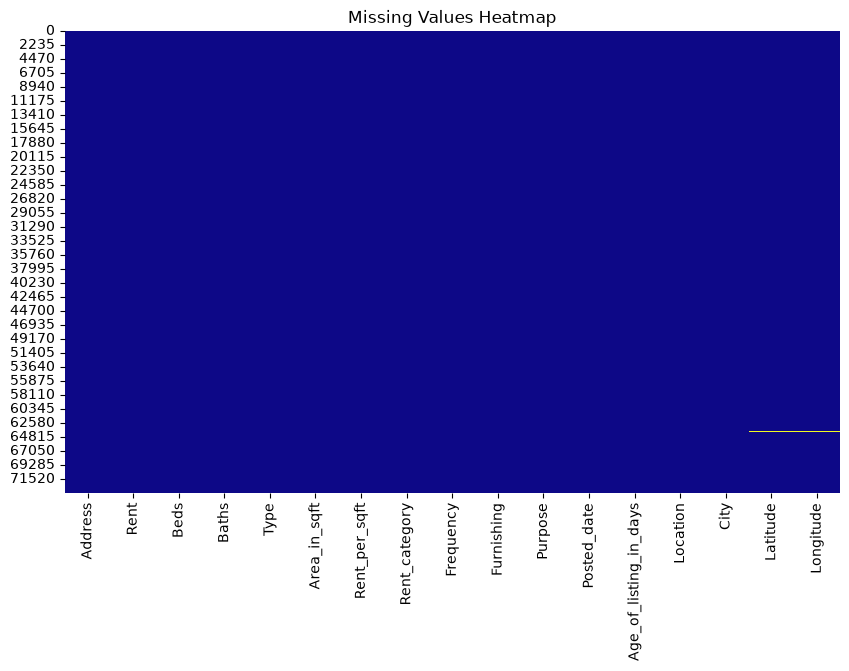

In [7]:
SimpleMissingValuesAnalysis().analyze(df)

Dataset Health: Excellent. The data is exceptionally clean, with zero null values across all features except for geographical coordinates.

Missing Data Profile:

Exactly 719 rows (< 1% of total data) contain missing values.

The missing data is exclusively limited to the Latitude and Longitude columns.

Concurrent Missingness: Heatmap analysis confirms that these missing values occur in the exact same rows (i.e., if a property is missing its latitude, it is also missing its longitude).

Conclusion for ML Engineering
From an engineering perspective, this is a very healthy dataset. Since the missing geographical coordinates only affect 719 rows (which is less than 1% of the ~73,742 total rows established in your previous inspection), so we have a few easy options for our pipeline:

Imputation: we could perform localized neighborhood imputation for the missing coordinates, dropping any orphaned rows that lack neighbors. 

Drop Rows: Given the tiny proportion of missing data, dropping these 719 rows entirely would likely have a negligible impact on your model's performance.

I added a new strategy in missing_values_analysis.py to check that

In [8]:
from analysis.analyze_src.basic_data_inspection import MissingCoordinatesNeighborStrategy # new strategy newly added


inspector = DataInspector(MissingCoordinatesNeighborStrategy())
inspector.execute_inspection(df)


Checking for Imputation Viability (Missing Coordinates):
                           Location  Valid_Neighbors_Available
Abu Dhabi Gate City (Officers City)                          0
                        Abu Krayyah                          0
                       Ajman Marina                          0
                       Ajman Uptown                          0
                        Al Agabiyya                          0
                Al Ain Oasis Villas                          0
                          Al Amerah                          0
                            Al Azra                          0
                           Al Bahia                        165
                          Al Butain                          1
                     Al Dana Island                          0
                    Al Dar Al Baida                          0
                           Al Defan                          0
                     Al Faseel Area                         

😞😞😞 It looks like we have hit the exact edge case we discussed before, but on a massive scale. The output clearly shows that for almost every location missing its coordinates (like Abu Dhabi Gate City or Ajman Marina), there are 0 valid neighbors. This means that my primary plan of imputing based on Location will fail for the vast majority of these 719 rows because there is no local data to average. i really wanted to keep these rows but sometimes, the most `state-of-the-art` decision is knowing when to let bad data go. Since these 719 rows make up less than 1% of your 73,000+ dataset, the safest and cleanest engineering decision is to simply drop them. Missing geographic data in a real estate model is risky to guess.

* Before we go further any, we need to pause and look closely at three specific attributes in our dataset: `Rent (our target), Area_in_sqft, and Rent_per_sqft`.

Here is the thing—from my experience building ML pipelines, a feature like Rent_per_sqft is almost always derived directly from the Rent itself. If we feed this feature to our model, it won't actually learn how things like location, bedrooms, or furnishing affect the price. Instead, it will just figure out the basic math formula `(Area * Rent_per_sqft)` and cheat.

If we don't pay close attention to this, we will end up training a "stupid model." It will look like a genius during testing with near-perfect accuracy, but it will completely break in the real world when a user tries to predict a price (because the user won't know the rent per square foot before knowing the total rent!).

Let's run a quick mathematical sanity check to confirm this leakage so we can safely drop the column:

##### 4. Leakage confirmation: Rent_per_sqft is derived from Rent/Area

In [9]:
diff = (df['Rent'] / df['Area_in_sqft'] - df['Rent_per_sqft']).abs()
print("Max difference (should be ~0):", diff.max())

Max difference (should be ~0): 2.2737367544323206e-13


That output is exactly what I was wondering. We got the confirmation that Rent_per_sqft is just a mathematical clone of our target variable. So before feeding our model it must be dropped

##### 5. Check for constant columns to confirm zero predictive value

Data Variance Check: Hunting for Useless Features

ML odels are essentially pattern-recognition engines. To find patterns and make accurate predictions, they rely on differences in the data. They need to know what makes a `$100,000` apartment look different from a `$50,000` apartment. 

If a feature has the exact same value for every single row in our dataset, it provides absolutely zero predictive power. We call these "Constant Columns," and leaving them in our dataset just wastes memory and compute time. Let's check the `Frequency` and `Purpose` columns to see how many unique values they hold, which will tell us if they are actually useful for our model.

In [10]:

print(df['Frequency'].nunique(), df['Purpose'].nunique())

1 1


Bingo. That tells us exactly what we need to know.
Since both printed `1`, it means every single property out of the 73,000+ rows has the exact same value for Frequency (likely something like "Yearly") and Purpose (likely "For Rent").

Because they never change, they are constant columns. They offer absolutely no clues to help our model distinguish a cheap apartment from an expensive one. If we leave them in, they just waste memory and computing power.

#### 5. Target distribution

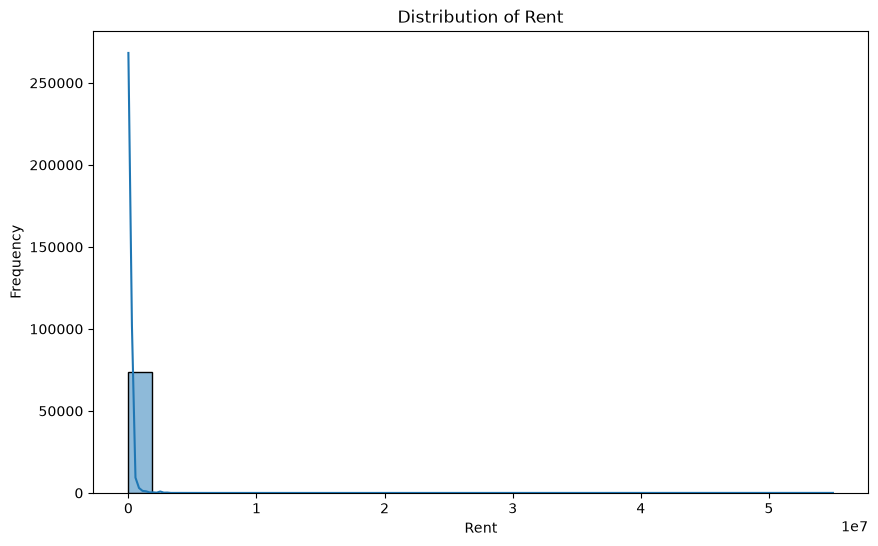

Skewness: 83.6922466741704


In [11]:
analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
analyzer.execute_analysis(df, "Rent")
print("Skewness:", df['Rent'].skew())

As the histogram and KDE (Kernel Density Estimate) curve clearly illustrate, our target variable (Rent) suffers from a severe right skew (positive skewness). The vast majority of the data is compressed against the left side of the graph, while a long, almost invisible tail of outliers stretches far to the right (reaching up to 55 million).

Why This Happens (The Real Estate Reality):
This distribution perfectly mirrors the reality of the UAE property market. The massive density on the left represents the typical market standard, everyday apartments and townhouses. The long tail trailing off to the right represents the ultra-luxury tier exclusive mega-villas and penthouses that make up a tiny fraction of the inventory but carry astronomical price tags.

The Risk to Model Performance:
Machine learning algorithms (especially linear models and neural networks) mathematically prefer normally distributed data (a symmetrical bell curve). If we feed this raw, highly skewed data into our model, the algorithm's mathematical loss function will panic. It will heavily penalize the model for missing the 55-million-dirham villa, forcing the model to shift its internal weights to compensate. As a result, the model will severely compromise its accuracy on the 99% of normal apartments just to accommodate a few extreme outliers.

To mitigate this in our upcoming preprocessing phase, we will apply a Logarithmic Transformation to the Rent column. This mathematical technique acts like a compressor: it drastically shrinks the massive numerical gaps of the luxury outliers while maintaining the correct relative differences in price. This will reshape our target variable into a healthy, digestible bell curve for training.

#### 6. Outlier detection on Rent and Area_in_sqft


Rent: 364 outliers detected (0.49% of rows)


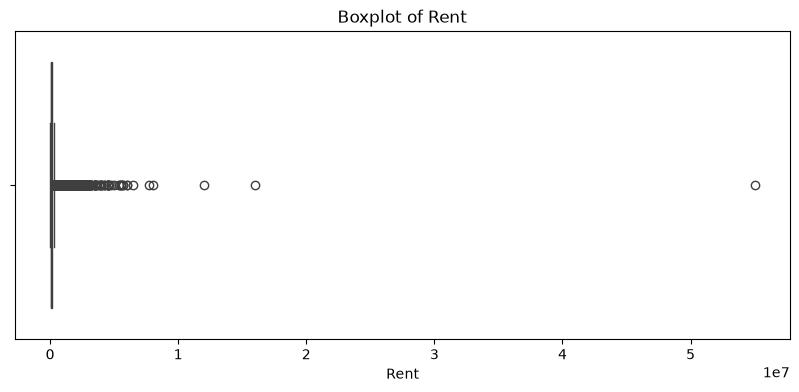


Area_in_sqft: 334 outliers detected (0.45% of rows)


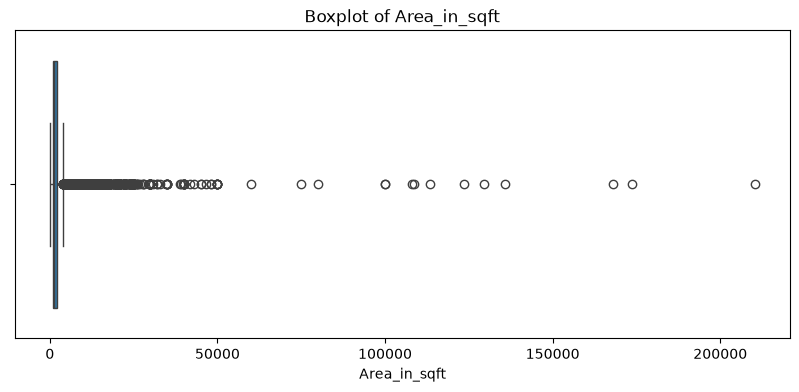

In [12]:
outlier_analyzer = OutlierAnalyzer(PercentileOutlierDetection(upper_percentile=0.995))
rent_outliers = outlier_analyzer.analyze(df, "Rent")
area_outliers = outlier_analyzer.analyze(df, "Area_in_sqft")

Both Rent and Area_in_sqft exhibit severe positive skewness with long right tails. The traditional IQR method would classify many valid high-value observations as outliers, potentially removing important information from the dataset. Therefore, a percentile-based approach (99.5th percentile) is more appropriate because it identifies only the most extreme observations (top 0.5%), reducing the influence of anomalous values while preserving the natural variability of the housing market.

#### 7. Geocoding sanity check, UAE lat range is ~22.5 to 26.5

In [13]:
bad_geo = df[(df['Latitude'] < 22) | (df['Latitude'] > 27)]
print(f"{len(bad_geo)} rows with implausible latitude")
print(bad_geo[['Address', 'City', 'Latitude', 'Longitude']])

140 rows with implausible latitude
                                Address     City   Latitude  Longitude
64194  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
64324  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
64394  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
64458  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
64618                   Al Tai, Sharjah  Sharjah  15.175847  43.351928
...                                 ...      ...        ...        ...
72652  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
72653  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
72720  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
72869  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928
73428  Nasma Residence, Al Tai, Sharjah  Sharjah  15.175847  43.351928

[140 rows x 4 columns]


We then identified 140 properties that claim to be in `Al Tai, Sharjah`, but have a Latitude of `15.17` and a Longitude of `43.35`.

If we plug those coordinates into Google Maps, we find out that this location isn't in the UAE at all. It is literally in the middle of Yemen (near the Red Sea)! So instead of throwing the data away, we can manually overwrite a known data error. We could hardcode the correct coordinates for the Al Tai neighborhood in Sharjah (which is approximately Latitude: `25.2922`, Longitude: `55.6027`). I mean it may not be a big deal but I prefer to make sure of the quality of the data. Because we are a reflexion of what we eat. Same applies to machine learning models. Let's make sure our model will eat good. Will take this into account when processing the dataset. Or maybe just drop it because city and location already capture location signals. but anyway will can decide later.

#### 8. Bivariate: Area vs Rent, Beds vs Rent

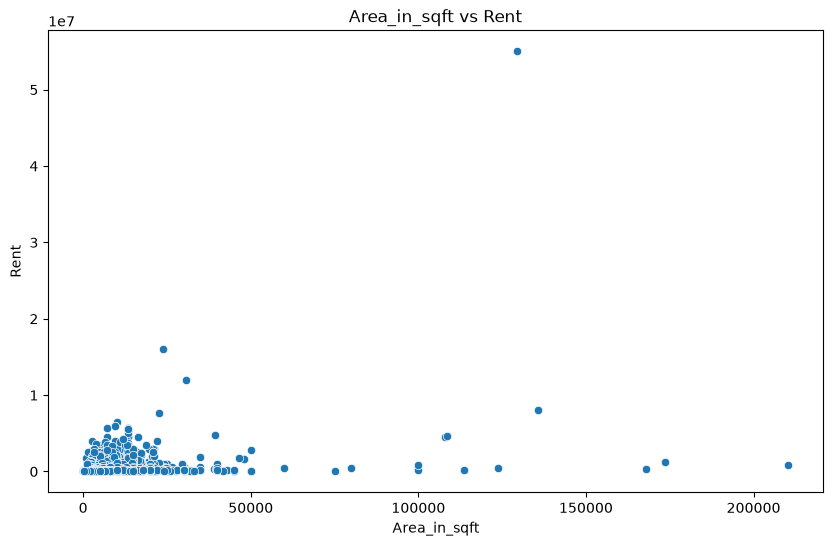

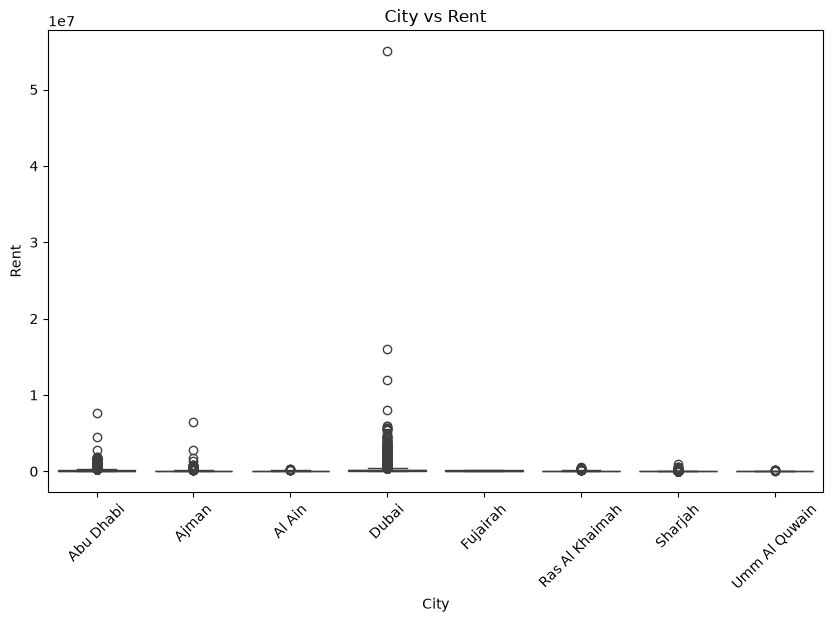

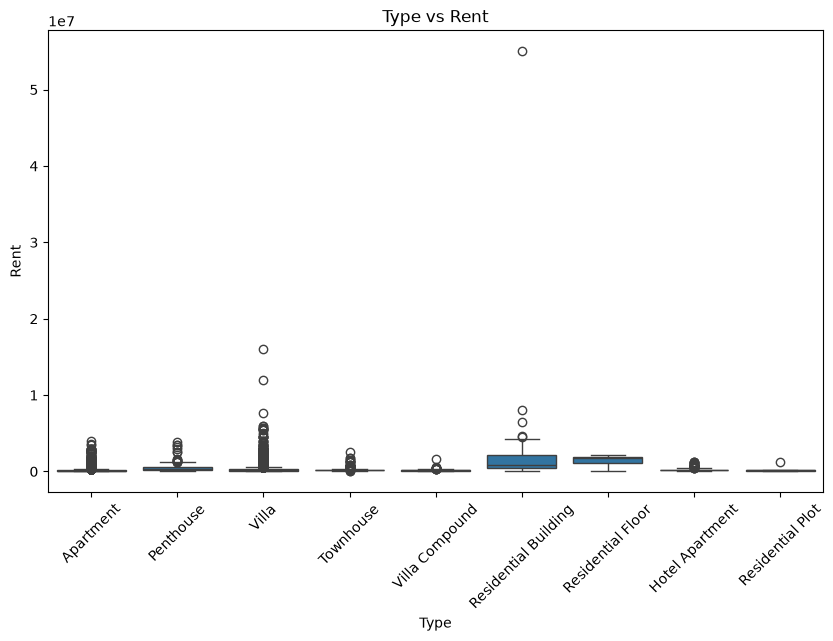

In [14]:
biv = BivariateAnalyzer(NumericalVsNumericalAnalysis())
biv.execute_analysis(df, "Area_in_sqft", "Rent")

biv.set_strategy(CategoricalVsNumericalAnalysis())
biv.execute_analysis(df, "City", "Rent")
biv.execute_analysis(df, "Type", "Rent")

1. Area_in_sqft vs Rent

The scatter plot shows a positive relationship between property area and rent, indicating that larger properties generally command higher rental prices. However, the relationship is not strictly linear, as properties with similar floor areas exhibit considerable variation in rent. This suggests that while area is an important determinant of rental price, other factors such as location, property type, amenities, and condition also play significant roles. The presence of several extreme observations with exceptionally large areas and rents further highlights the highly skewed nature of the dataset.
Property size has a positive influence on rent, but it is not the sole factor determining rental prices. The wide dispersion of points indicates that rent is influenced by multiple property characteristics beyond floor area.

2. City vs Rent

Rental prices vary significantly by city, with Dubai having the highest variability and the most expensive properties. This suggests that geographical location is a major factor influencing rental prices.

3. Type vs Rent

The distribution of rents differs considerably across property types. Residential Buildings exhibit the highest median rents and the greatest variability, along with several extreme outliers representing premium properties. Residential Floors also have relatively high rental values. Villas display a wide range of rents, reflecting differences in size, location, and luxury level. In contrast, Apartments, Townhouses, Hotel Apartments, and Villa Compounds generally show lower median rents with comparatively less variation.
Property type has a substantial impact on rental prices. Larger residential property categories such as residential buildings and villas tend to command higher rents and exhibit greater variability than apartments and other residential property types.

#### 9. Multivariate correlation (numeric features only, EXCLUDING Rent_per_sqft to avoid distorting the picture with leakage)

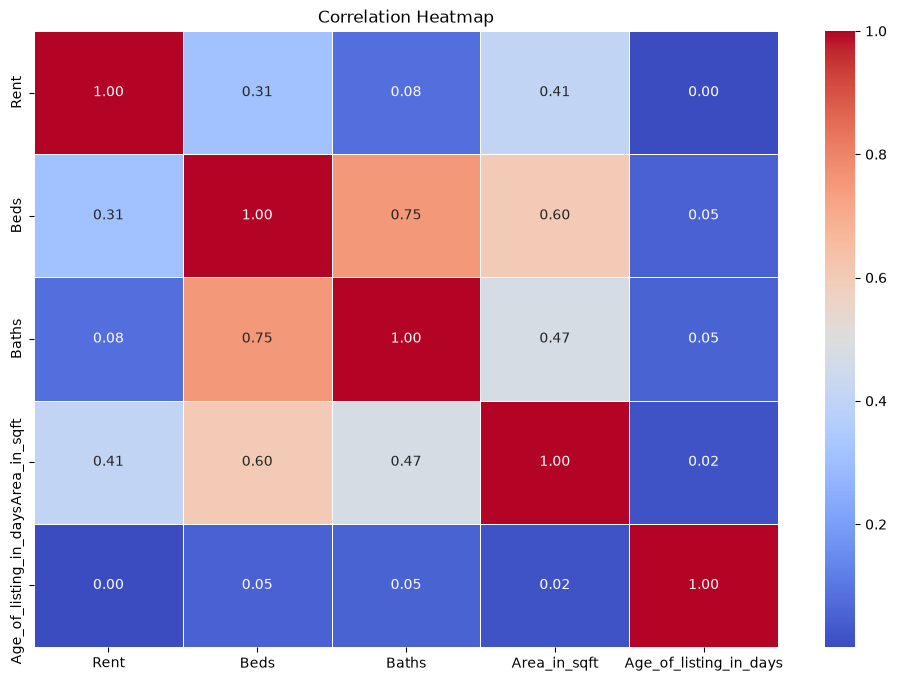

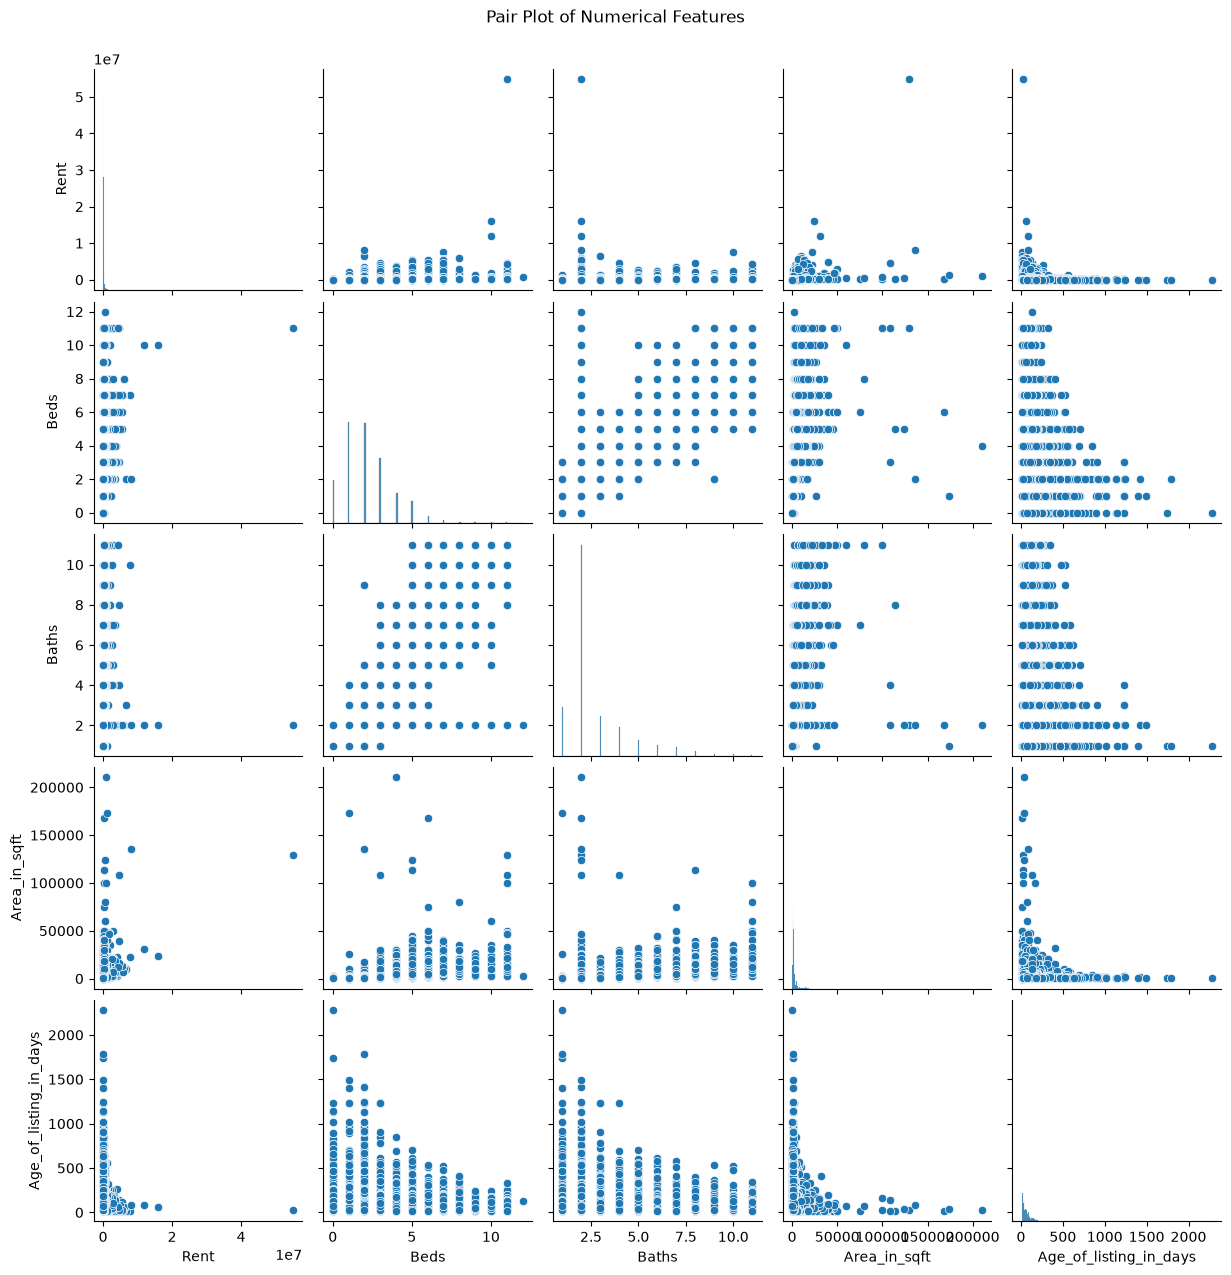

In [15]:
numeric_cols = ['Rent', 'Beds', 'Baths', 'Area_in_sqft', 'Age_of_listing_in_days']
SimpleMultivariateAnalysis().analyze(df[numeric_cols])

The correlation analysis indicates that property size (Area_in_sqft) is the strongest numerical predictor of rental price among the available features, followed by the number of bedrooms. The number of bathrooms and the listing age contribute relatively little to explaining rental price. Additionally, the strong correlation between Beds and Baths suggests that these features capture related information about property size and layout.

The pair plot confirms that Area_in_sqft, Beds, and Baths are positively related, with larger properties generally having more bedrooms and bathrooms. Rent tends to increase with property size and bedroom count, although the relationships are influenced by substantial variability and several extreme observations. Meanwhile, the age of a listing shows little to no association with the other numerical features, suggesting that it has limited predictive value for rental price.

#### 10. Location cardinality check, help decide encoding strategy

In [16]:
print("Unique Address:", df['Address'].nunique())
print("Unique Location:", df['Location'].nunique())
print("Unique City:", df['City'].nunique())
print(df['Location'].value_counts().head(15))

Unique Address: 4515
Unique Location: 441
Unique City: 8
Location
Al Reem Island                   3668
Jumeirah Village Circle (JVC)    3117
Downtown Dubai                   3003
Khalifa City                     2751
Dubai Marina                     2600
Business Bay                     2152
Muwailih Commercial              2055
Mohammed Bin Zayed City          2054
Al Raha Beach                    1808
Dubai Creek Harbour              1736
Palm Jumeirah                    1614
Meydan City                      1609
Muwaileh                         1378
Yas Island                       1178
Dubai Hills Estate               1070
Name: count, dtype: int64


The distribution is heavily long-tailed

Out of `441` total unique locations, just `15` of them (top locations like Al Reem Island, JVC, Downtown Dubai) already cover `43.1% of all 73,742 listings`.
`38` locations cover `64.6%` of the data.
`120` locations (roughly a quarter of all unique locations) cover `90.9%` of the data.
The remaining `321` locations (`73%` of all unique location names) together account for only `9.1%` of listings meaning most of these locations individually have just a handful of rows each. In fact, `168` locations have fewer than `10` listings way too few to let a model learn anything reliable about them specifically.